In [5]:
# import basic libraries and autograd wrapped numpy
import autograd.numpy as np
import copy
import matplotlib.pyplot as plt


# this is needed to compensate for matplotlib notebook's tendancy to blow up images when plotted inline
%matplotlib notebook
from matplotlib import rcParams
rcParams['figure.autolayout'] = True

In [94]:
def quadratic(x):
    return np.dot(x, x)

def sample_uniform(P, N):
    return np.random.uniform(low=-1, high=1, size=(P, N))

def sample_random(P, N):
    return np.random.randn(P, N) 

def run(f, p, n=100):
    out = []
    for i in range(1, n + 1):
        x = f(p, i)
        y = np.apply_along_axis(quadratic, 1, x)
        out.append(y.min())
    return out

# Solve part (a)

mins_uniform_100 = run(sample_uniform, p=100)

<IPython.core.display.Javascript object>


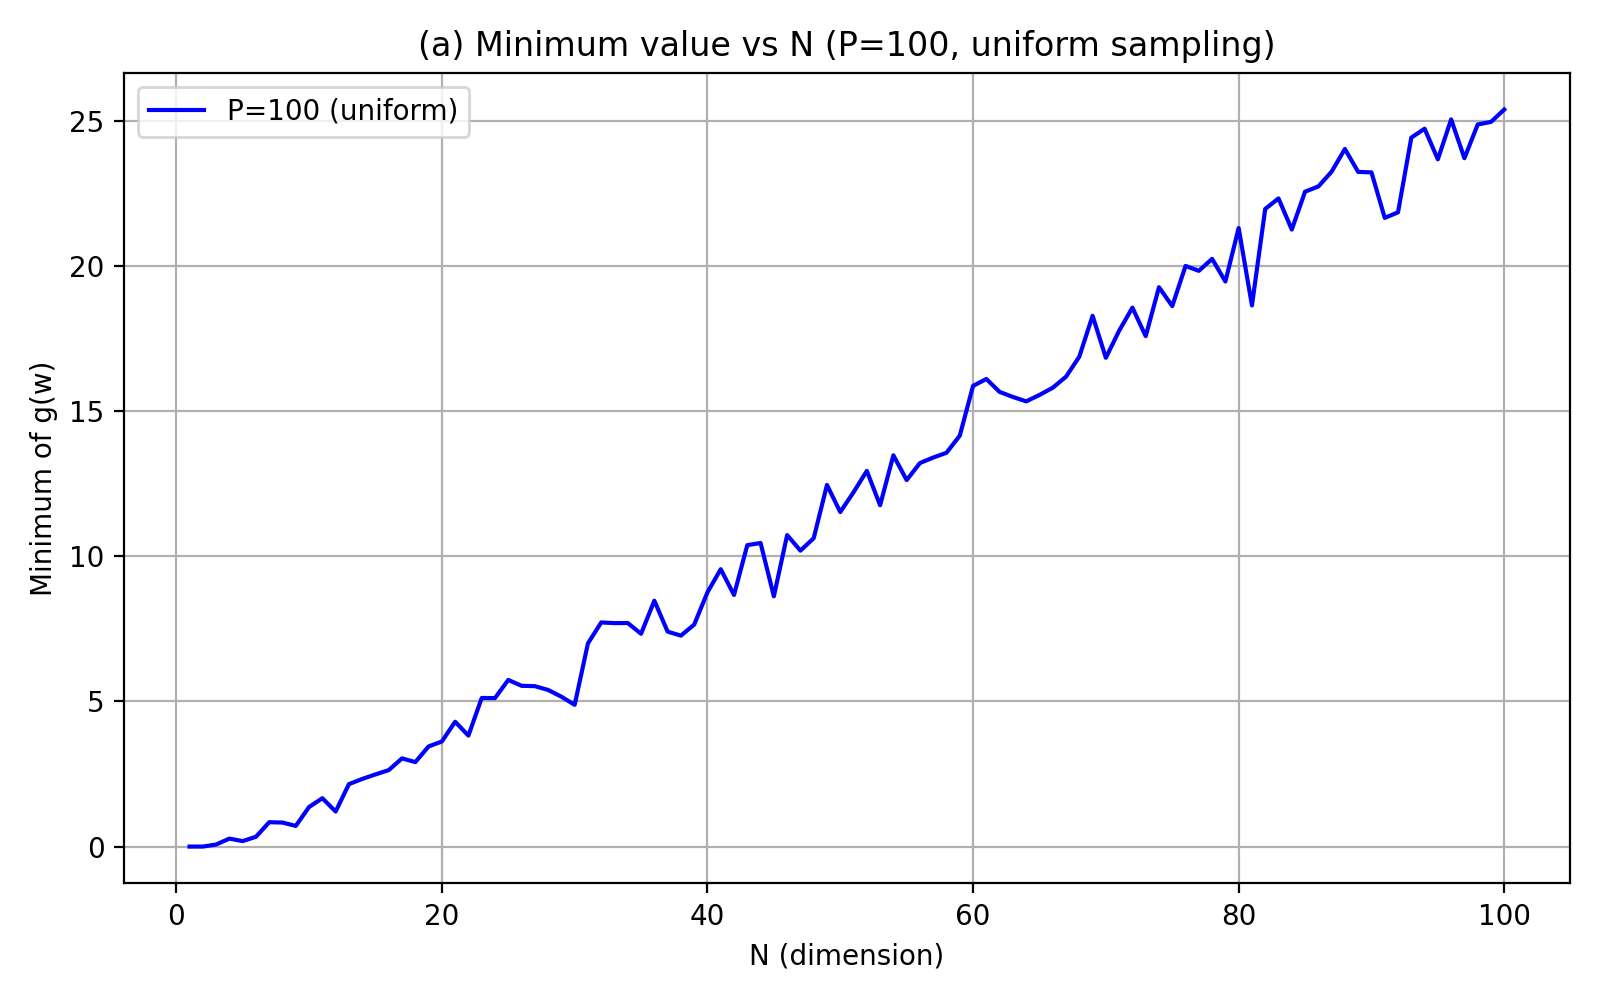

In [97]:
# Plot (a)
plt.figure(figsize=(8, 5))
plt.plot(range(1, 101), mins_uniform_100, label='P=100 (uniform)', color='blue')
plt.title("(a) Minimum value vs N (P=100, uniform sampling)")
plt.xlabel("N (dimension)")
plt.ylabel("Minimum of g(w)")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# Solve part (b)

mins_uniform_100 = run(sample_uniform, p=100)
mins_uniform_1000 = run(sample_uniform, p=1000)
mins_uniform_10000 = run(sample_uniform, p=10000)

<IPython.core.display.Javascript object>


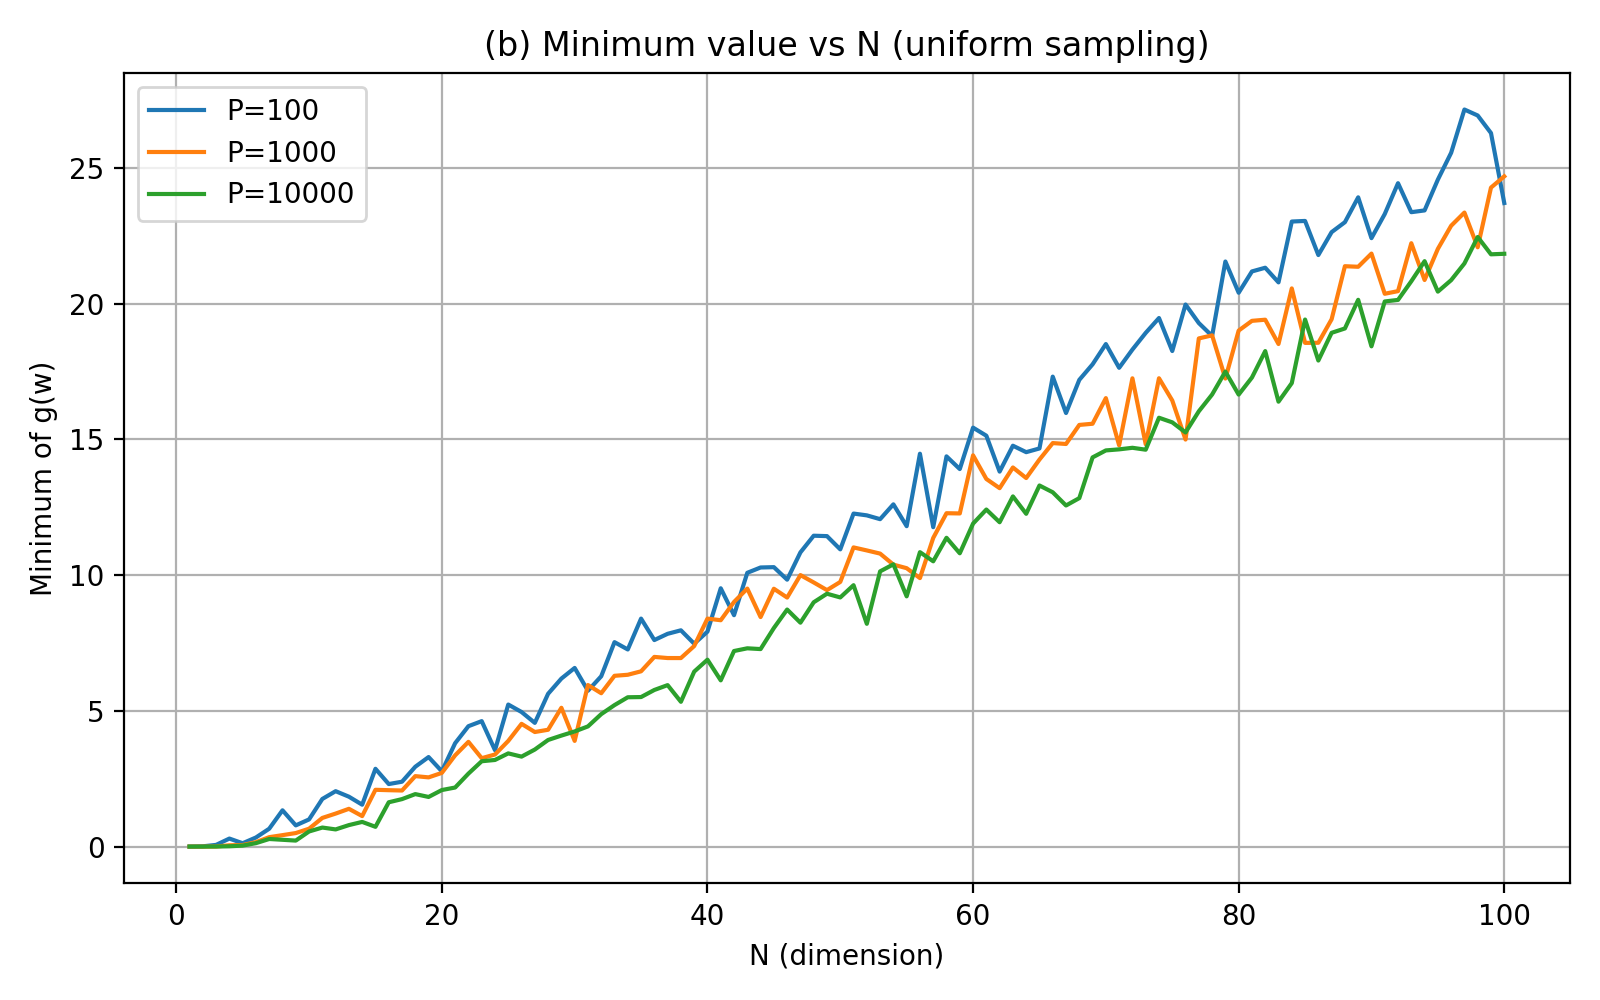

In [92]:
# Solve part (b)

mins_uniform_1000 = run(sample_uniform, p=1000)
mins_uniform_10000 = run(sample_uniform, p=10000)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 101), mins_uniform_100, label='P=100')
plt.plot(range(1, 101), mins_uniform_1000, label='P=1000')
plt.plot(range(1, 101), mins_uniform_10000, label='P=10000')
plt.title("(b) Minimum value vs N (uniform sampling)")
plt.xlabel("N (dimension)")
plt.ylabel("Minimum of g(w)")
plt.grid(True)
plt.legend()
plt.show()



<IPython.core.display.Javascript object>


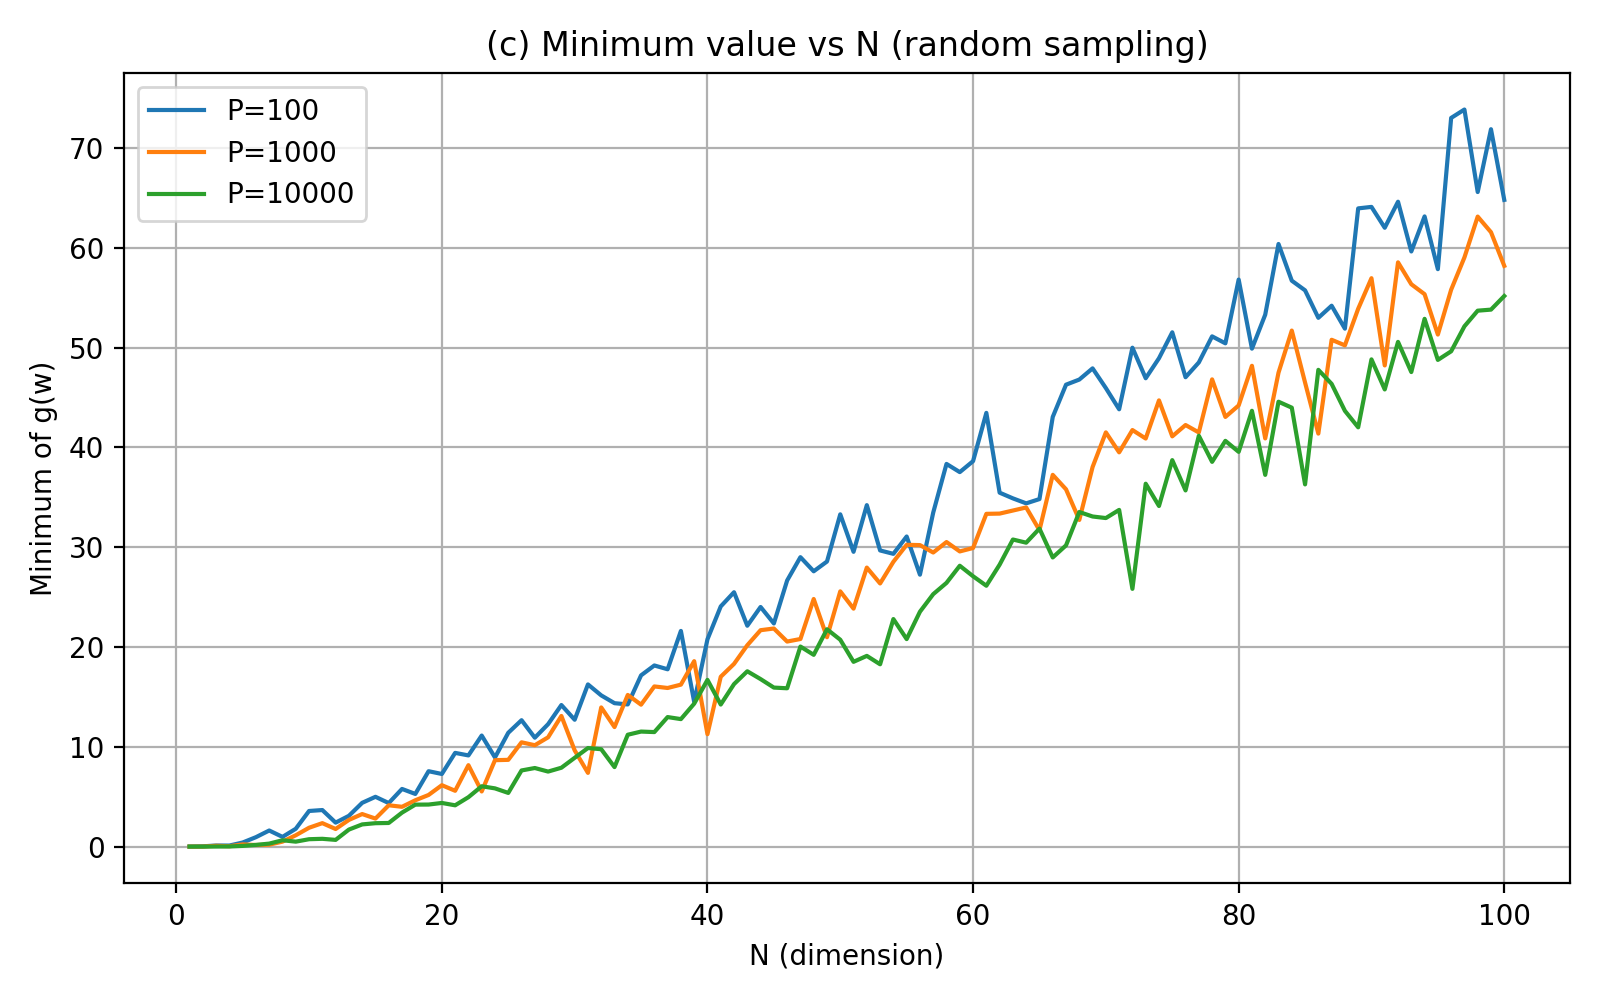

In [93]:
# Solve part (c)
mins_random_100 = run(sample_random, p=100)
mins_random_1000 = run(sample_random, p=1000)
mins_random_10000 = run(sample_random, p=10000)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 101), mins_random_100, label='P=100')
plt.plot(range(1, 101), mins_random_1000, label='P=1000')
plt.plot(range(1, 101), mins_random_10000, label='P=10000')
plt.title("(c) Minimum value vs N (random sampling)")
plt.xlabel("N (dimension)")
plt.ylabel("Minimum of g(w)")
plt.grid(True)
plt.legend()
plt.show()

<IPython.core.display.Javascript object>


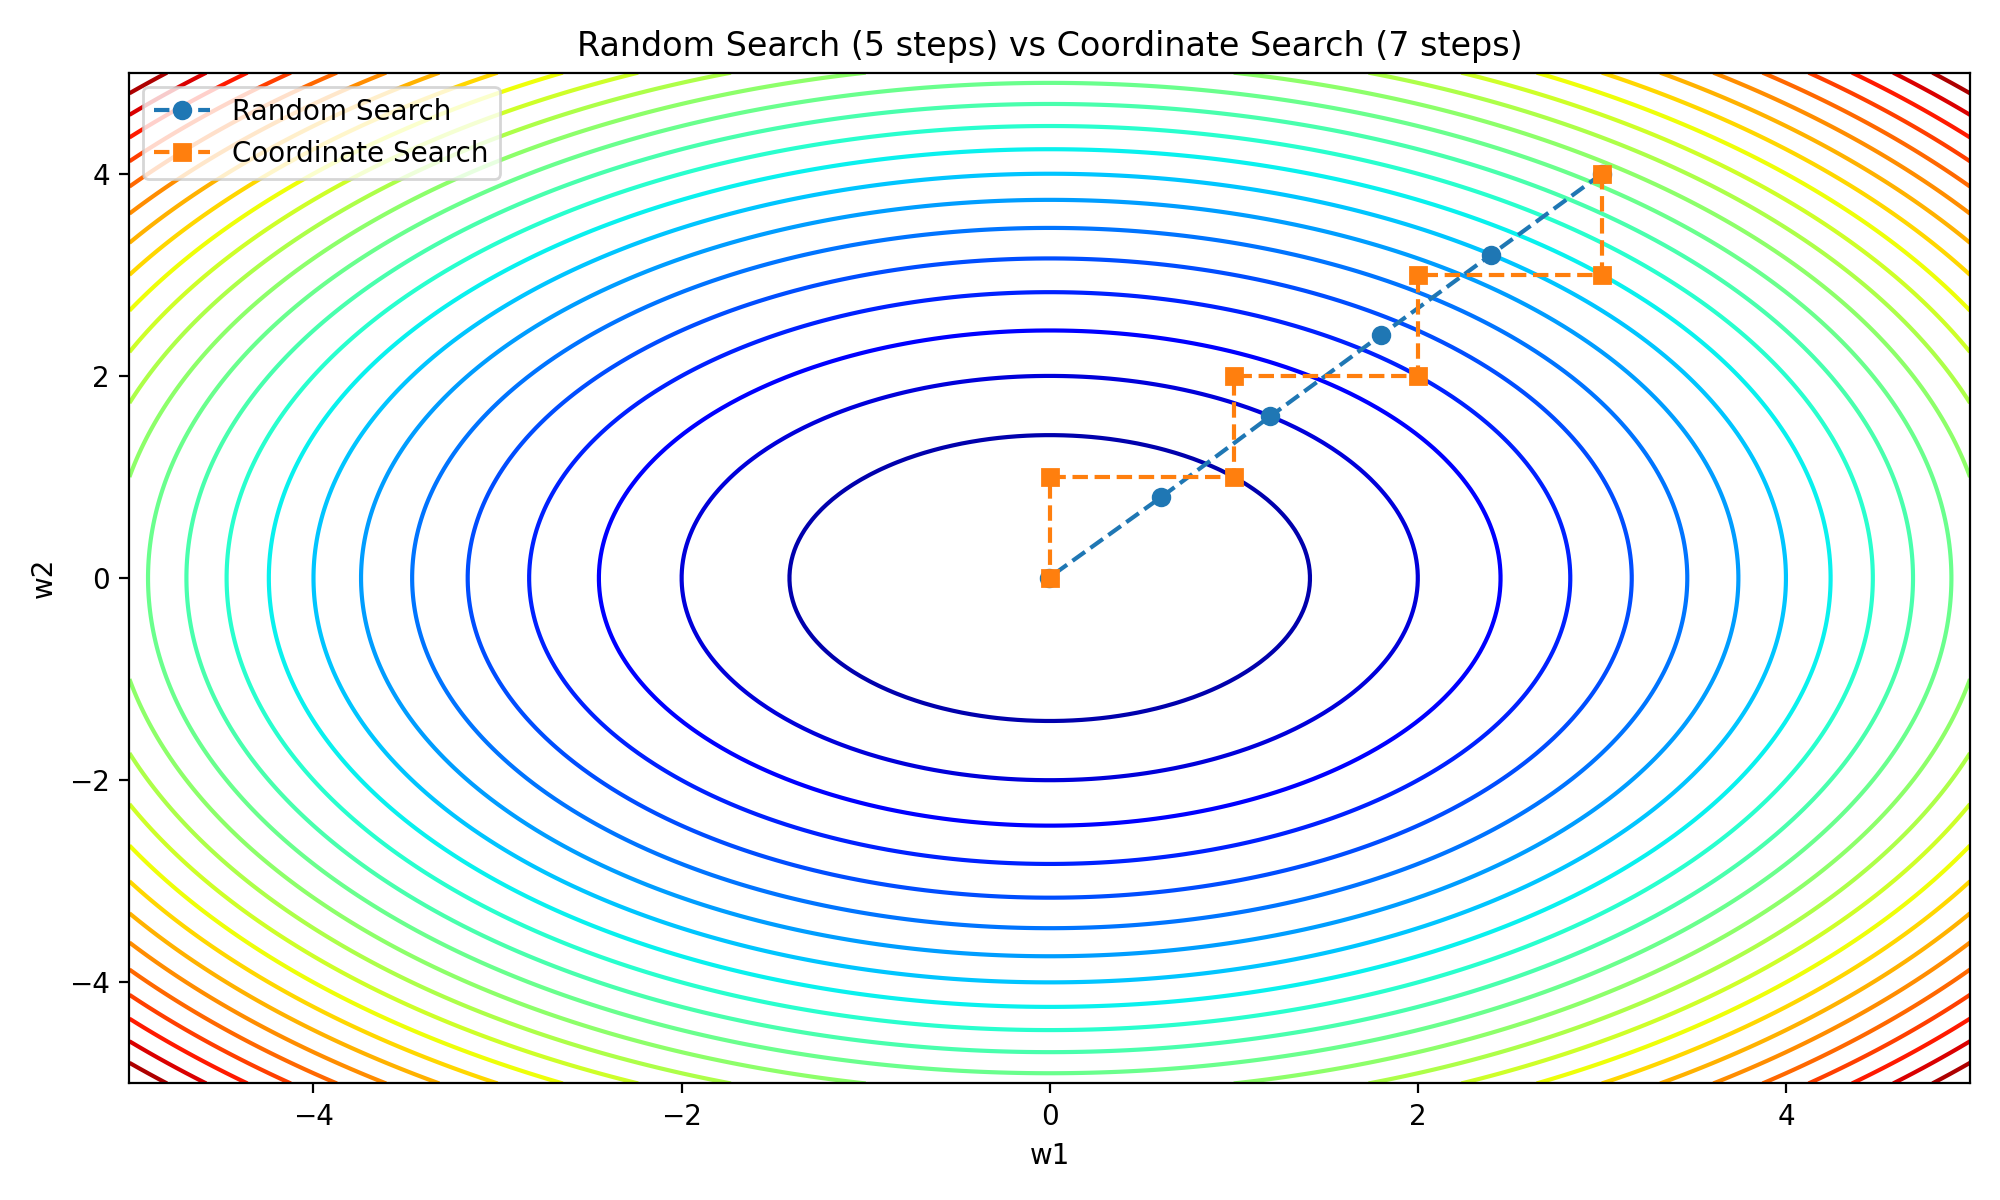

In [100]:
def g(w):
    return w[0]**2 + w[1]**2 + 2

# zero order coordinate search
def coordinate_search(g, alpha, max_its, w):
    # construct set of all coordinate directions
    directions_plus = np.eye(np.size(w), np.size(w))
    directions_minus = -np.eye(np.size(w), np.size(w))
    directions = np.concatenate((directions_plus, directions_minus), axis=0)
        
    # run coordinate search
    weight_history = []         # container for weight history
    cost_history = []           # container for corresponding cost function history
    for k in range(1, max_its+1):                    
        # record weights and cost evaluation
        weight_history.append(w.copy())
        cost_history.append(g(w))
        
        ### pick best descent direction
        candidates = []
        values = []
        
        for d in directions:
            w_new = w + alpha * d
            candidates.append(w_new)
            values.append(g(w_new))
        
        # pick the best candidate
        values = np.array(values)
        min_index = np.argmin(values)
        if values[min_index] < g(w):
            w = candidates[min_index]   # update if descent found
    
    # record final
    weight_history.append(w.copy())
    cost_history.append(g(w))
    return np.array(weight_history), np.array(cost_history)

# random search function
def random_search(g, alpha, max_its, w, num_samples):
    # run random search
    weight_history = []         # container for weight history
    cost_history = []           # container for corresponding cost function history
    
    for k in range(1, max_its+1):                    
        # record weights and cost evaluation
        weight_history.append(w.copy())
        cost_history.append(g(w))
        
        # construct set of random unit directions
        directions = np.random.randn(num_samples, len(w))           # shape: (num_samples, dim)
        directions /= np.linalg.norm(directions, axis=1)[:, None]   # normalize to unit vectors
        w_candidates = [w + alpha * d for d in directions]          # candidate points
        
        ### pick best descent direction
        # evaluate all candidates
        evals = np.array([g(w_val) for w_val in w_candidates])

        # check directions to ensure a real descent direction to take the step in its direction
        min_index = np.argmin(evals)
        if evals[min_index] < g(w):
            w = w_candidates[min_index]
            
    # record weights and cost evaluation
    weight_history.append(w.copy())
    cost_history.append(g(w))
    return np.array(weight_history), np.array(cost_history)

import matplotlib.pyplot as plt

# initial point
w0 = np.array([3.0, 4.0])
alpha = 1

# run random search (5 steps)
rand_w_hist, rand_c_hist = random_search(g, alpha, max_its=5, w=w0.copy(), num_samples=1000)

# run coordinate search (7 steps)
coord_w_hist, coord_c_hist = coordinate_search(g, alpha, max_its=7, w=w0.copy())

# plot contours of g
w1 = np.linspace(-5,5,200)
w2 = np.linspace(-5,5,200)
W1, W2 = np.meshgrid(w1,w2)
Z = W1**2 + W2**2 + 2

plt.figure(figsize=(10,6))
plt.contour(W1, W2, Z, levels=30, cmap='jet')

# random search path
plt.plot(rand_w_hist[:,0], rand_w_hist[:,1], 'o--', label="Random Search")
# coordinate search path
plt.plot(coord_w_hist[:,0], coord_w_hist[:,1], 's--', label="Coordinate Search")

plt.legend()
plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Random Search (5 steps) vs Coordinate Search (7 steps)")
plt.show()


<IPython.core.display.Javascript object>


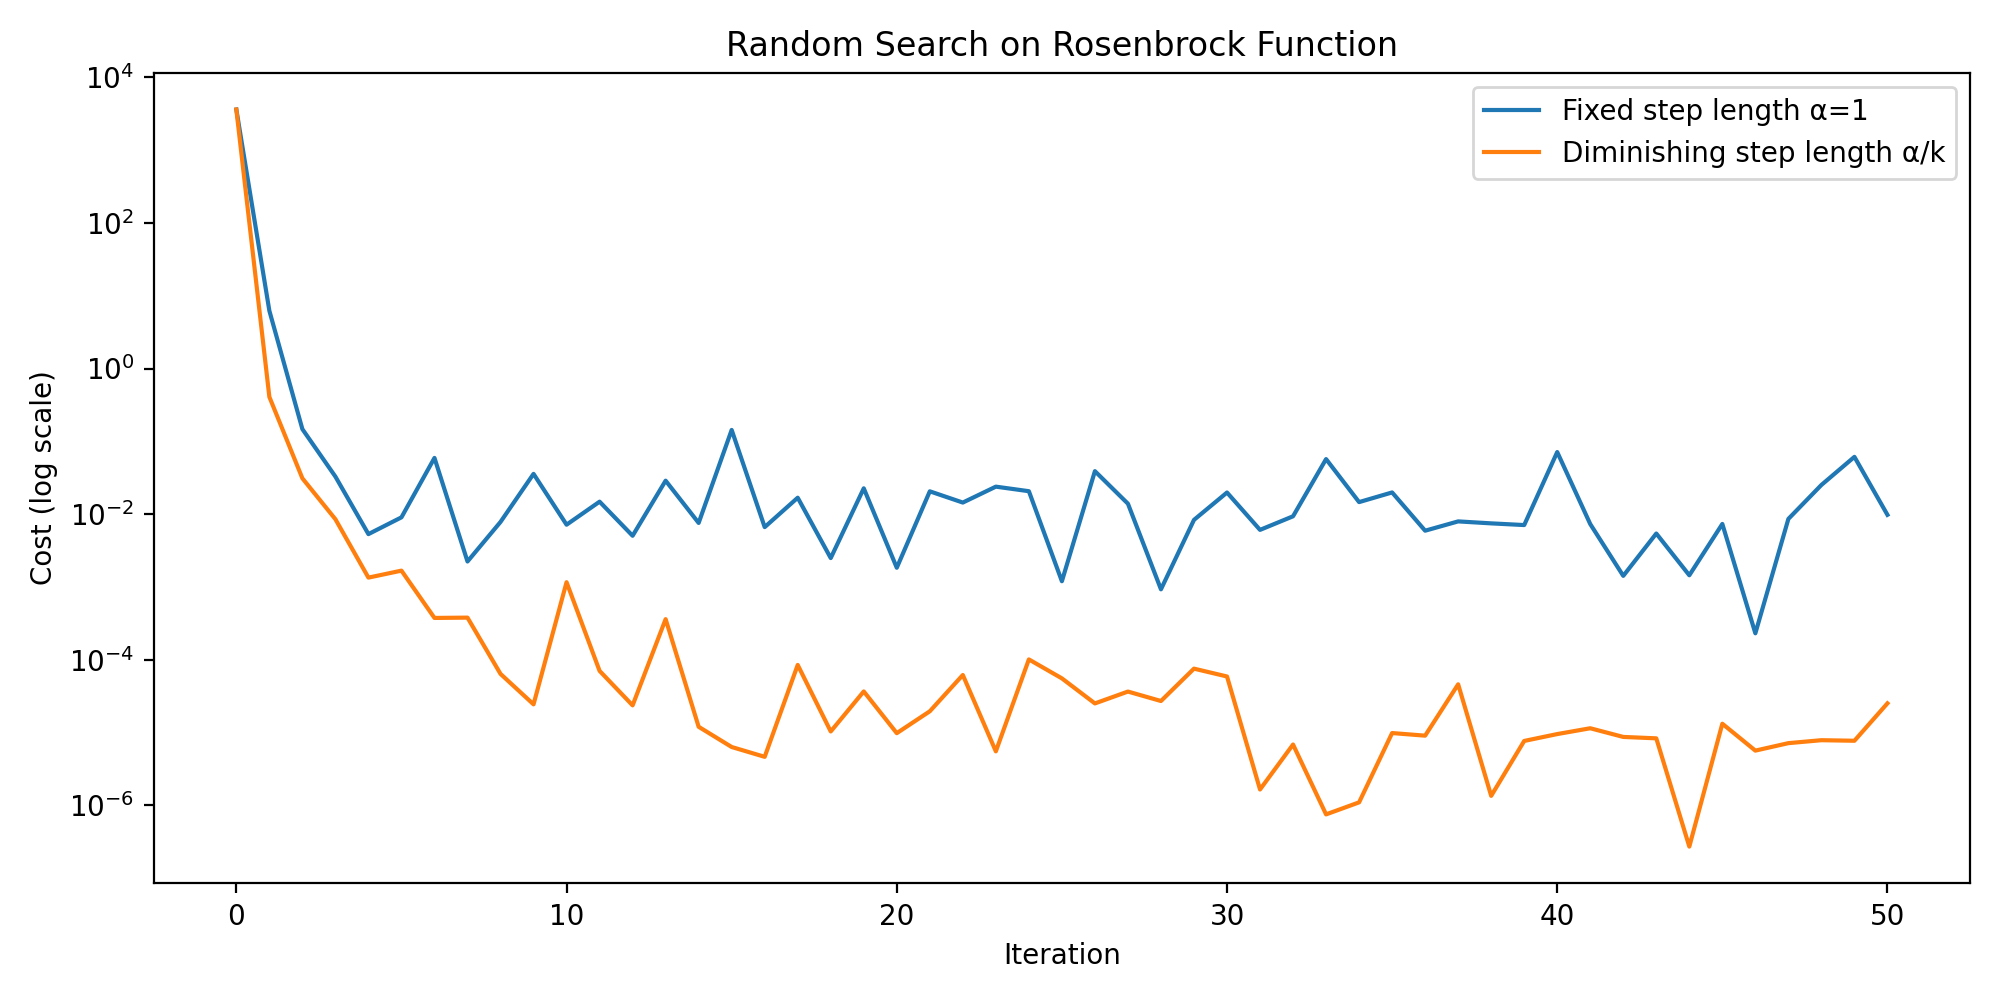

In [62]:
def rosenbrock(w):
    w1, w2 = w
    return 100*(w2 - w1**2)**2 + (w1 - 1)**2

def random_search(g, w0, K, P=1000, alpha=1.0, diminishing=False):
    w = np.array(w0)
    cost_history = [g(w)]
    weight_history = [w]

    for k in range(1, K+1):
        if diminishing:
            step_length = alpha / k  
        else:
            step_length = alpha       

        candidates = w + step_length * np.random.randn(P, len(w))
        costs = np.apply_along_axis(g, 1, candidates)

        best_idx = np.argmin(costs)
        w = candidates[best_idx]

        cost_history.append(costs[best_idx])
        weight_history.append(w)

    return np.array(weight_history), np.array(cost_history)


w0 = [-2, -2]
K = 50
P = 1000

weights_fixed, costs_fixed = random_search(rosenbrock, w0, K, P, alpha=1.0, diminishing=False)

weights_dim, costs_dim = random_search(rosenbrock, w0, K, P, alpha=1.0, diminishing=True)

plt.figure(figsize=(10,5))
plt.plot(costs_fixed, label="Fixed step length α=1")
plt.plot(costs_dim, label="Diminishing step length α/k")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Cost (log scale)")
plt.title("Random Search on Rosenbrock Function")
plt.legend()
plt.show()


<IPython.core.display.Javascript object>


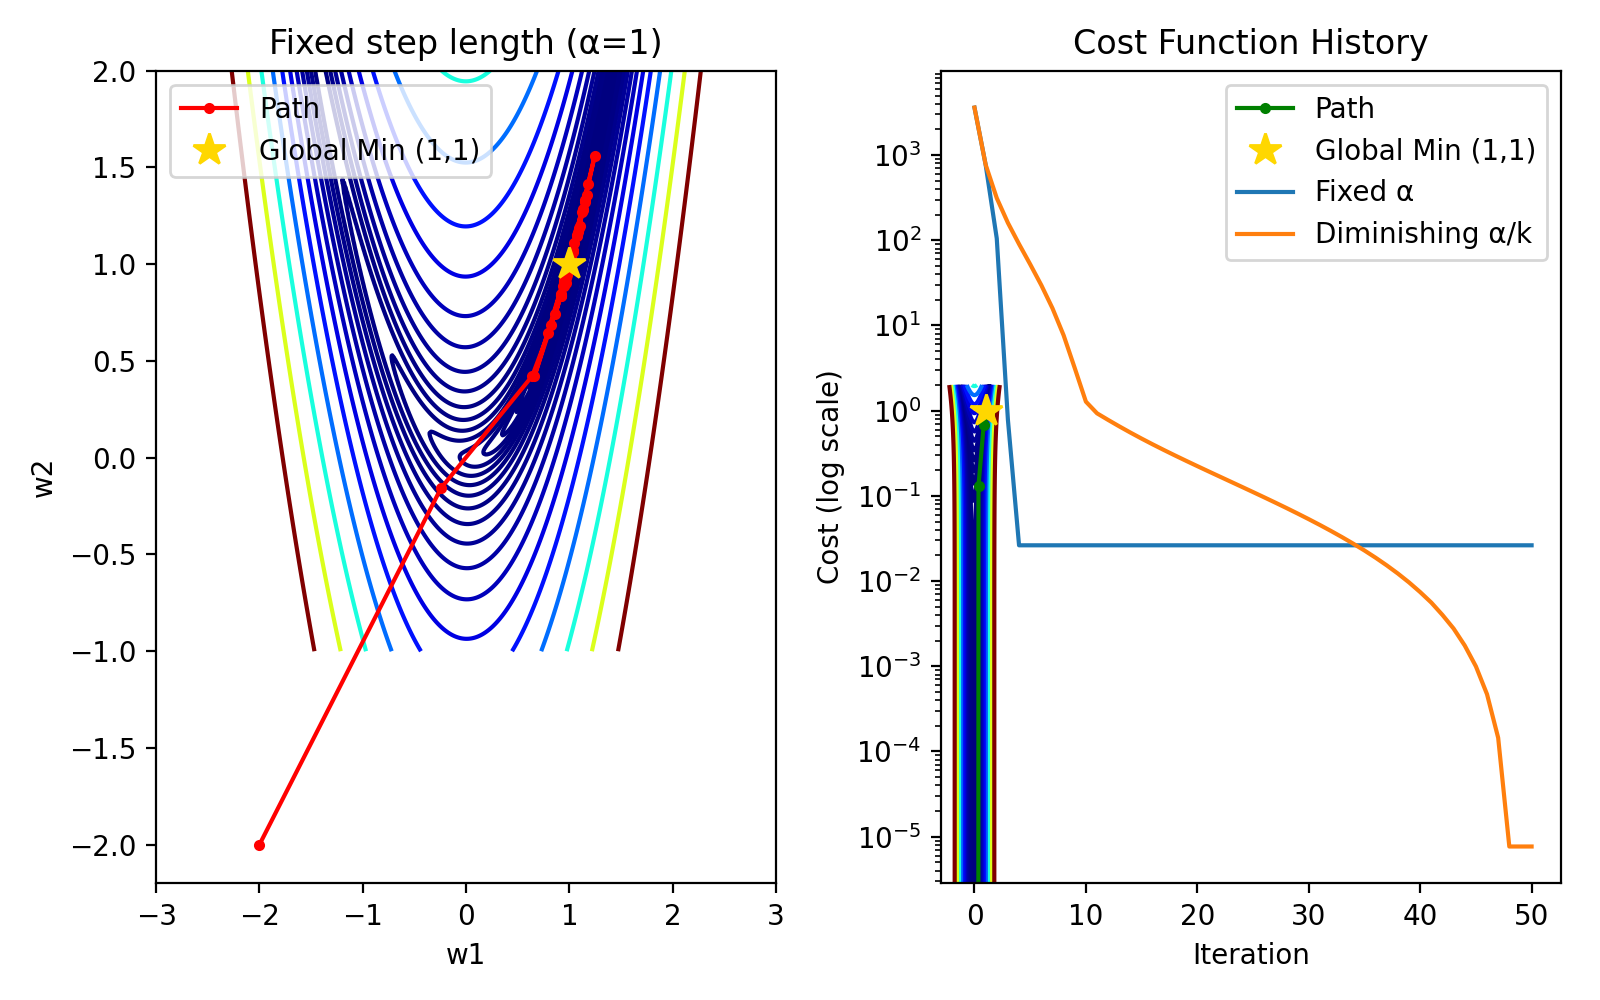

In [65]:
def plot_contour(g, weights_fixed, weights_dim):
    w1 = np.linspace(-3, 3, 400)
    w2 = np.linspace(-1, 2, 400)
    W1, W2 = np.meshgrid(w1, w2)
    Z = g([W1, W2])

    plt.figure(figsize=(8,5))

    plt.subplot(1,2,1)
    plt.contour(W1, W2, Z, levels=np.logspace(-1, 3, 20), cmap="jet")
    plt.plot(weights_fixed[:,0], weights_fixed[:,1], "o-", color="red", markersize=3, label="Path")
    plt.plot(1,1,"*",color="gold",markersize=12,label="Global Min (1,1)")
    plt.title("Fixed step length (α=1)")
    plt.xlabel("w1")
    plt.ylabel("w2")
    plt.legend()

    plt.subplot(1,2,2)
    plt.contour(W1, W2, Z, levels=np.logspace(-1, 3, 20), cmap="jet")
    plt.plot(weights_dim[:,0], weights_dim[:,1], "o-", color="green", markersize=3, label="Path")
    plt.plot(1,1,"*",color="gold",markersize=12,label="Global Min (1,1)")
    plt.title("Diminishing step length (α/k)")
    plt.xlabel("w1")
    plt.ylabel("w2")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_contour(rosenbrock, weights_fixed, weights_dim)


In [71]:
def rosenbrock(w):
    w1, w2 = w
    return 100*(w2 - w1**2)**2 + (w1 - 1)**2

# Random search (fixed or diminishing)
def random_search(g, alpha, max_its, w, num_samples, diminishing=False):
    weight_history = []         # container for weight history
    cost_history = []           # container for corresponding cost function history
    w = np.array(w)             

    for k in range(1, max_its + 1):                    
        weight_history.append(w)
        cost_history.append(g(w))

        step_size = alpha / k if diminishing else alpha

        directions = np.random.randn(num_samples, len(w))
        directions /= np.linalg.norm(directions, axis=1)[:, np.newaxis]

        w_candidates = [w + step_size * d for d in directions]
        evals = np.array([g(w_val) for w_val in w_candidates])

        best_idx = np.argmin(evals)
        if evals[best_idx] < g(w):
            w = w_candidates[best_idx]

    weight_history.append(w)
    cost_history.append(g(w))
    return np.array(weight_history), np.array(cost_history)

<IPython.core.display.Javascript object>


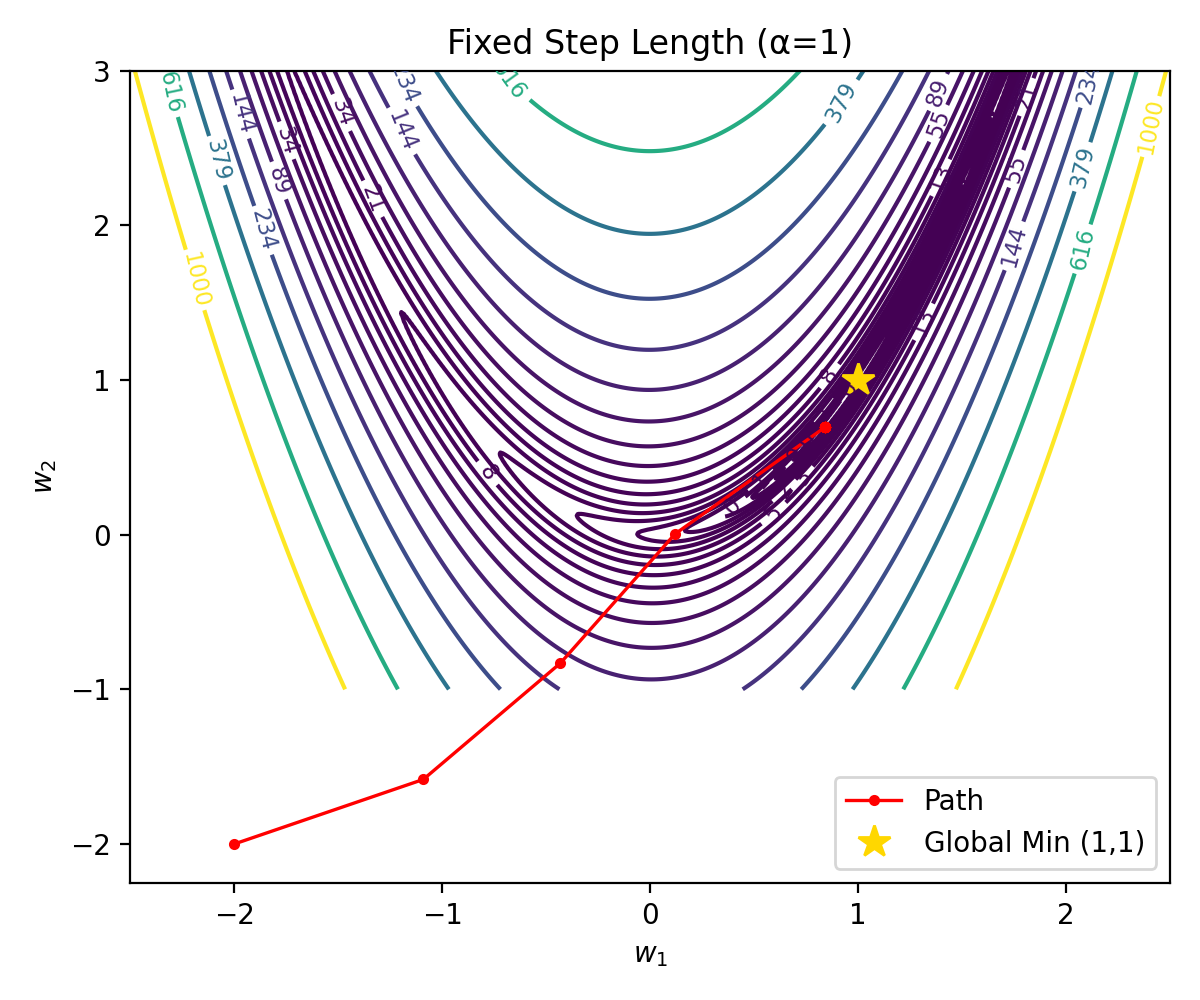

<IPython.core.display.Javascript object>


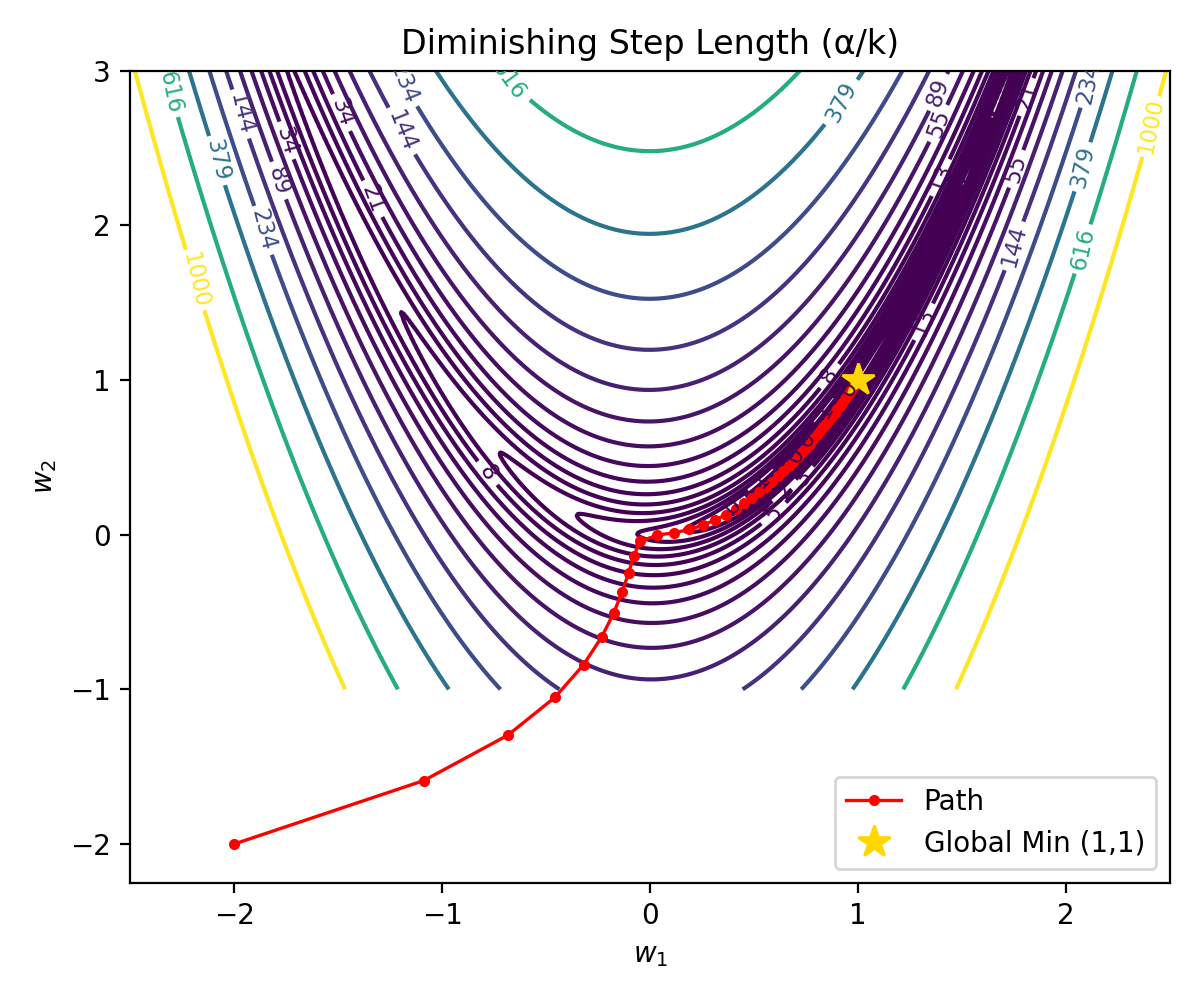

In [74]:
def plot_contour(g, weight_history, title="Random Search Path"):
    w1 = np.linspace(-2.5, 2.5, 400)
    w2 = np.linspace(-1, 3, 400)
    W1, W2 = np.meshgrid(w1, w2)
    Z = g([W1, W2])

    plt.figure(figsize=(6,5))
    CS = plt.contour(W1, W2, Z, levels=np.logspace(-1, 3, 20), cmap="viridis")
    plt.clabel(CS, inline=1, fontsize=8, fmt="%.0f")

    weight_history = np.array(weight_history)
    plt.plot(weight_history[:,0], weight_history[:,1], "o-", color="red", markersize=3, linewidth=1.2, label="Path")
    plt.plot(1,1,"*",color="gold",markersize=12,label="Global Min (1,1)")

    plt.xlabel("$w_1$")
    plt.ylabel("$w_2$")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    
alpha = 1.0
max_its = 50
num_samples = 1000
w0 = np.array([-2, -2])

weights_fixed, costs_fixed = random_search(rosenbrock, alpha, max_its, w0, num_samples, diminishing=False)
weights_dim, costs_dim = random_search(rosenbrock, alpha, max_its, w0, num_samples, diminishing=True)



plot_contour(rosenbrock, weights_fixed, title="Fixed Step Length (α=1)")
plot_contour(rosenbrock, weights_dim, title="Diminishing Step Length (α/k)")


<IPython.core.display.Javascript object>


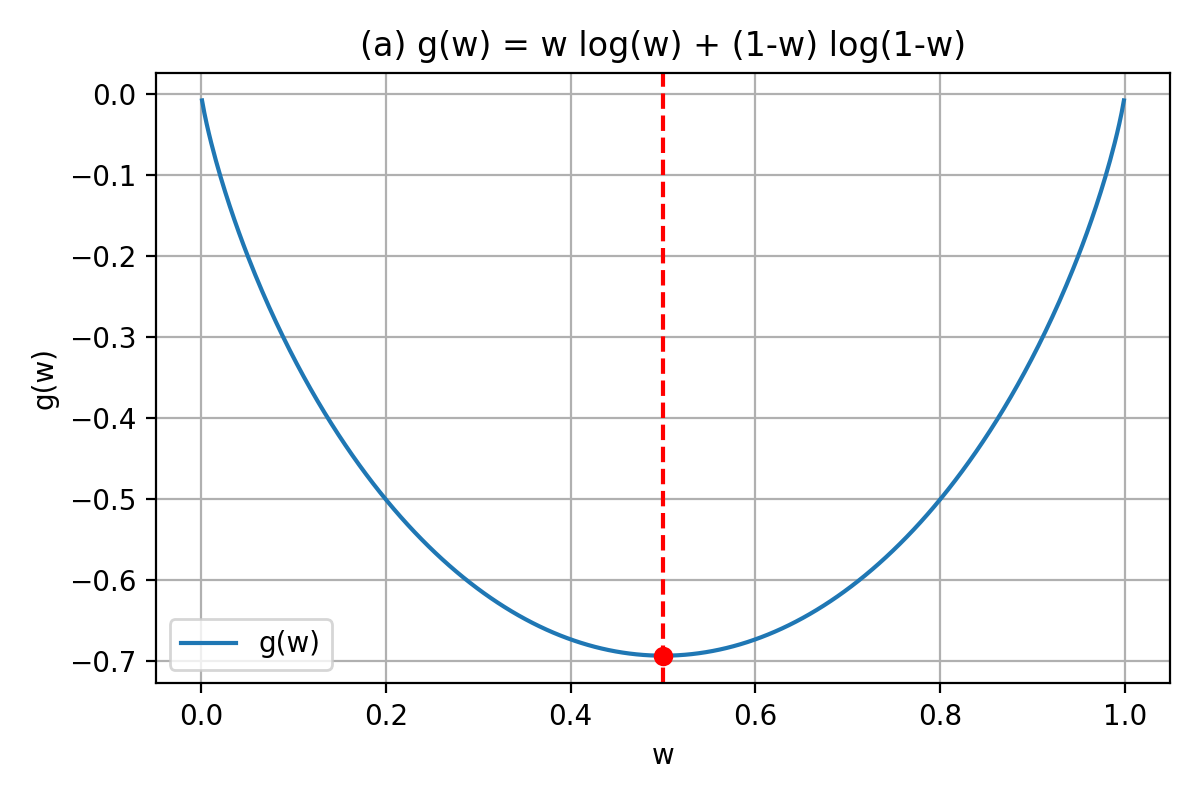

In [103]:
import numpy as np
import matplotlib.pyplot as plt

# (a)
w = np.linspace(0.001, 0.999, 400)   # 避免 log(0)
g_a = w*np.log(w) + (1-w)*np.log(1-w)

plt.figure(figsize=(6,4))
plt.plot(w, g_a, label="g(w)")
plt.axvline(0.5, color="r", linestyle="--")
plt.scatter([0.5], [np.log(0.5)], color="r", zorder=5)
plt.title("(a) g(w) = w log(w) + (1-w) log(1-w)")
plt.xlabel("w"); plt.ylabel("g(w)")
plt.legend(); plt.grid(True)
plt.show()
